# Solutions: Probability & Non-Probability Sampling

Worked solutions to every exercise in the **Skeleton** notebook, with
explanations of *why* each answer is correct — not just the code. Try the
skeleton yourself first; this notebook is most useful for checking your
approach or getting unstuck.


## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(2020)


## The running example: a field of plants

Throughout this lab we reuse the field-of-plants scenario from *Building
Statistical Models in Python* (Chapter 1). A farmer has a rectangular field
split into three plots — **A**, **B**, and **C**:

- **Plot A** sits next to a forest, so those plants get slightly **less
  sunlight**.
- **Plot B** sits between the primary irrigation lines, so those plants get
  **more water**.
- **Plot C** sits next to a road, so those plants are exposed to **dust and
  runoff**.

These are the *confounding variables* the book describes — real effects that
make one part of the field systematically different from another. Because we
are simulating the field ourselves, we know the **true population mean
yield**. That lets us score every sampling method by how close its estimate
comes to the truth — something you can never do with a real population.


### Exercise 1 — solution

`np.repeat(["A", "B", "C"], N // 3)` produces 300 `"A"`s, then 300 `"B"`s,
then 300 `"C"`s — exactly the contiguous blocks described. `cluster_id`
uses integer division on the row position so every run of 30 consecutive
rows shares one cluster id. The three effect arrays use `np.where` to add
a fixed offset only to the plot they describe; everything else is left at
the shared baseline plus random noise.


In [2]:
N = 900

plot = np.repeat(["A", "B", "C"], N // 3)
cluster_id = np.arange(N) // 30 + 1

forest_effect     = np.where(plot == "A", -5.0, 0.0)
irrigation_effect = np.where(plot == "B",  8.0, 0.0)
road_effect       = np.where(plot == "C", -2.0, 0.0)

base_yield = 50.0
noise = rng.normal(0, 6, size=N)
yield_kg = base_yield + forest_effect + irrigation_effect + road_effect + noise

population = pd.DataFrame({
    "plant_id": np.arange(1, N + 1),
    "plot": plot,
    "cluster_id": cluster_id,
    "yield_kg": yield_kg,
})
population.head()


,plant_id,plot,cluster_id,yield_kg
0,1,A,1,52.561240
1,2,A,1,46.339071
2,3,A,1,52.995292
3,4,A,1,36.490772
4,5,A,1,43.363218


### Exercise 2 — solution

In [3]:
POP_MEAN = population["yield_kg"].mean()
POP_STD = population["yield_kg"].std(ddof=0)
print(f"mu = {POP_MEAN:.3f}, sigma = {POP_STD:.3f}")


mu = 50.211, sigma = 8.186


## 2. Simple random sampling

### Exercise 3 — solution

`rng.choice` is called on the DataFrame's **index**, not the values, so we
can use the returned labels with `.loc` to pull the matching rows.
`replace=False` is essential — otherwise the same plant could be drawn
twice, which is not how simple random sampling without replacement works.


In [4]:
def simple_random_sample(df, n, rng):
    idx = rng.choice(df.index, size=n, replace=False)
    return df.loc[idx]

n = 90
srs = simple_random_sample(population, n, rng)
print(f"SRS mean: {srs['yield_kg'].mean():.3f} (true: {POP_MEAN:.3f})")


SRS mean: 51.781 (true: 50.211)


## 3. Systematic sampling

### Exercise 4 — solution


In [5]:
def systematic_sample(df, n, rng):
    N = len(df)
    k = N // n
    start = rng.integers(0, k)
    return df.iloc[np.arange(start, N, k)[:n]]

sys_sample = systematic_sample(population, n, rng)
print(f"Systematic mean: {sys_sample['yield_kg'].mean():.3f}")


Systematic mean: 49.509


### Exercise 5 — sample answer

Systematic sampling walks through the list at a fixed interval. If the list
was, say, sorted by *planting date* and yield varies smoothly with plant
age (older plants yield more), then every k-th plant sampled would tend to
land on a similar age bracket relative to the seasons — inflating or
deflating the estimate depending on where the random start happens to fall.
The book's own example is a class roster where top math students land on
every 10th number; the general principle is: **systematic sampling is safe
only when the list order has no relationship to the variable you're
measuring.**


## 4. Stratified sampling

### Exercise 6 — solution

`groupby` isolates each stratum; drawing an independent SRS inside each
group and concatenating the results is exactly proportional stratified
sampling. Because `frac` is applied per group, the strata's relative sizes
are preserved in the sample.


In [6]:
def stratified_sample(df, strata_col, frac, rng):
    parts = []
    for level, group in df.groupby(strata_col):
        n_g = int(round(frac * len(group)))
        idx = rng.choice(group.index, size=n_g, replace=False)
        parts.append(df.loc[idx])
    return pd.concat(parts)

frac = n / N
strat_sample = stratified_sample(population, "plot", frac, rng)
print(f"Stratified mean: {strat_sample['yield_kg'].mean():.3f}")
strat_sample.groupby("plot").size()


Stratified mean: 50.289


plot
A    30
B    30
C    30
dtype: int64

## 5. Cluster sampling

### Exercise 7 — solution

Stage one selects whole clusters (the sub-rows). Stage two, if requested,
re-uses `stratified_sample` treating `cluster_id` as the "strata" — a neat
trick since sampling a fraction *within* each selected cluster is
structurally identical to stratified sampling.


In [7]:
def cluster_sample(df, cluster_col, n_clusters, rng, stage2_frac=None):
    clusters = df[cluster_col].unique()
    chosen = rng.choice(clusters, size=n_clusters, replace=False)
    sample = df[df[cluster_col].isin(chosen)]
    if stage2_frac is not None:
        sample = stratified_sample(sample, cluster_col, stage2_frac, rng)
    return sample

clus_sample = cluster_sample(population, "cluster_id", 3, rng)
two_stage_sample = cluster_sample(population, "cluster_id", 9, rng, stage2_frac=1/3)
print(f"Cluster mean (1-stage, n={len(clus_sample)}): {clus_sample['yield_kg'].mean():.3f}")
print(f"Cluster mean (2-stage, n={len(two_stage_sample)}): {two_stage_sample['yield_kg'].mean():.3f}")


Cluster mean (1-stage, n=90): 45.731
Cluster mean (2-stage, n=90): 49.323


## 6. Non-probability sampling

### Exercise 8 — solution


In [8]:
def convenience_sample(df, n, accessible_plot="C"):
    accessible = df[df["plot"] == accessible_plot]
    return accessible.sort_values("plant_id").head(n)

conv_sample = convenience_sample(population, n)
print(f"Convenience mean: {conv_sample['yield_kg'].mean():.3f} "
      f"(true: {POP_MEAN:.3f}) -- biased toward Plot C's road effect")


Convenience mean: 47.972 (true: 50.211) -- biased toward Plot C's road effect


### Exercise 9 — solution

In [9]:
def quota_sample(df, strata_col, quotas):
    parts = [df[df[strata_col] == lvl].sort_values("plant_id").head(n_g)
             for lvl, n_g in quotas.items()]
    return pd.concat(parts)

quotas = {"A": 30, "B": 30, "C": 30}
quota_sample_df = quota_sample(population, "plot", quotas)
print(f"Quota mean: {quota_sample_df['yield_kg'].mean():.3f}")


Quota mean: 50.184


## 7. Monte Carlo comparison

### Exercise 10 — solution

`run_trials` calls the sampler repeatedly and stores the resulting sample
mean each time — that array *is* the empirical sampling distribution.
Bias is how far its average sits from the truth; the standard deviation of
that array is the estimate's variability; MSE combines both into one
comparable score.


In [10]:
N_TRIALS = 1000

def run_trials(sampler_fn, n_trials=N_TRIALS):
    means = np.empty(n_trials)
    for i in range(n_trials):
        means[i] = sampler_fn()["yield_kg"].mean()
    return means

methods = {
    "Simple random":     run_trials(lambda: simple_random_sample(population, n, rng)),
    "Systematic":        run_trials(lambda: systematic_sample(population, n, rng)),
    "Stratified":        run_trials(lambda: stratified_sample(population, "plot", frac, rng)),
    "Cluster (1-stage)": run_trials(lambda: cluster_sample(population, "cluster_id", 3, rng)),
    "Convenience":       run_trials(lambda: convenience_sample(population, n)),
    "Quota":             run_trials(lambda: quota_sample(population, "plot", quotas)),
}

summary = pd.DataFrame({
    "mean_of_sample_means": {k: v.mean() for k, v in methods.items()},
    "bias": {k: v.mean() - POP_MEAN for k, v in methods.items()},
    "std_dev_of_estimate": {k: v.std(ddof=1) for k, v in methods.items()},
})
summary["mse"] = summary["bias"] ** 2 + summary["std_dev_of_estimate"] ** 2
summary.sort_values("mse").round(3)


,mean_of_sample_means,bias,std_dev_of_estimate,mse
Quota,50.184,-0.027,0.000,0.001
Systematic,50.190,-0.022,0.520,0.271
Stratified,50.206,-0.005,0.605,0.366
Simple random,50.173,-0.038,0.802,0.644
Convenience,47.972,-2.240,0.000,5.016
Cluster (1-stage),50.303,0.092,3.165,10.023


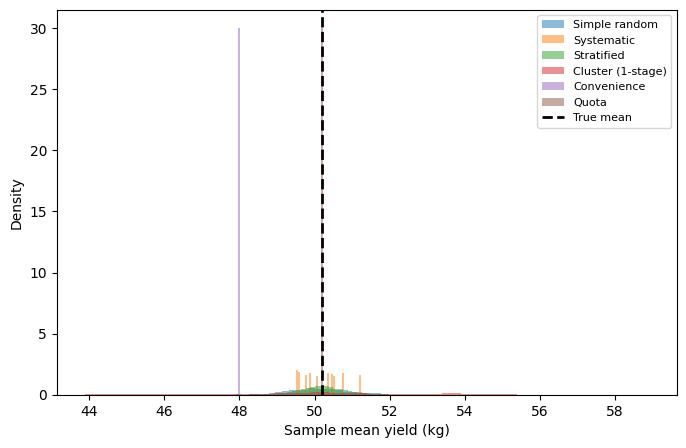

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))
for name, means in methods.items():
    ax.hist(means, bins=30, alpha=0.5, label=name, density=True)
ax.axvline(POP_MEAN, color="black", linestyle="--", linewidth=2, label="True mean")
ax.set_xlabel("Sample mean yield (kg)")
ax.set_ylabel("Density")
ax.legend(fontsize=8)
plt.show()


**Reading the results:** Stratified sampling should post the lowest (or
near-lowest) MSE because it eliminates between-plot variation from the
sampling error. Cluster sampling is unbiased but noisy — expect its
`std_dev_of_estimate` to be several times larger than SRS or stratified.
Convenience sampling will show a `bias` clearly different from zero and,
misleadingly, a *small* variance — it is consistently wrong in the same
direction every time, which is worse than being noisy but centered.


## 8. Confidence interval

### Exercise 11 — solution


In [12]:
from scipy import stats

one_sample = stratified_sample(population, "plot", frac, rng)
x_bar = one_sample["yield_kg"].mean()
s = one_sample["yield_kg"].std(ddof=1)
n_obs = len(one_sample)

t_crit = stats.t.ppf(0.975, df=n_obs - 1)
margin = t_crit * s / np.sqrt(n_obs)
ci_low, ci_high = x_bar - margin, x_bar + margin

print(f"x_bar={x_bar:.3f}, 95% CI=({ci_low:.3f}, {ci_high:.3f})")
print(f"Contains true mean? {ci_low <= POP_MEAN <= ci_high}")


x_bar=49.834, 95% CI=(48.065, 51.602)
Contains true mean? True


### Exercise 12 — solution

In [13]:
hits = 0
trials = 500
for _ in range(trials):
    s = stratified_sample(population, "plot", frac, rng)
    xb, sd, nobs = s["yield_kg"].mean(), s["yield_kg"].std(ddof=1), len(s)
    tcrit = stats.t.ppf(0.975, df=nobs - 1)
    m = tcrit * sd / np.sqrt(nobs)
    if xb - m <= POP_MEAN <= xb + m:
        hits += 1

print(f"Empirical coverage: {hits/trials:.1%} (target: 95%)")


Empirical coverage: 98.6% (target: 95%)


Coverage should land close to 95%, small-sample noise aside. This is the
formal justification for calling it a "95% confidence interval": **over
repeated probability sampling**, about 95% of the intervals you'd construct
this way contain the true parameter. This guarantee only holds because the
sampling was random — it would not hold for the convenience or quota
samples from Section 6.


## 9. Reflection — sample answers

1. **Most precise, can visit anywhere:** stratified sampling — it removes
   the largest known source of variation (plot) from the sampling error.
2. **Clusters are compact, travel is expensive:** cluster sampling — you
   pay travel cost per *cluster visited*, not per unit, at the price of
   higher variance, which you can offset with more (smaller) clusters
   rather than fewer (larger) ones.
3. **Convenience/quota and inference:** the formulas for standard errors,
   t-critical values, and p-values all assume each unit had a known,
   nonzero probability of selection. Convenience and quota samples violate
   that assumption, so even though the arithmetic still "runs," the
   resulting interval or p-value has no guaranteed relationship to the true
   population — you can't say what it's 95% confident *about*.
